In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [2]:
df = pd.read_csv("imdb_top_1000.csv")
df.head()


,Poster_Link,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross
0,https://m.media-amazon.com/images/M/MV5BMDFkYT...,The Shawshank Redemption,1994,A,142 min,Drama,9.3,Two imprisoned men bond over a number of years...,80.0,Frank Darabont,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler,2343110,"28,341,469"
1,https://m.media-amazon.com/images/M/MV5BM2MyNj...,The Godfather,1972,A,175 min,"Crime, Drama",9.2,An organized crime dynasty's aging patriarch t...,100.0,Francis Ford Coppola,Marlon Brando,Al Pacino,James Caan,Diane Keaton,1620367,"134,966,411"
2,https://m.media-amazon.com/images/M/MV5BMTMxNT...,The Dark Knight,2008,UA,152 min,"Action, Crime, Drama",9.0,When the menace known as the Joker wreaks havo...,84.0,Christopher Nolan,Christian Bale,Heath Ledger,Aaron Eckhart,Michael Caine,2303232,"534,858,444"
3,https://m.media-amazon.com/images/M/MV5BMWMwMG...,The Godfather: Part II,1974,A,202 min,"Crime, Drama",9.0,The early life and career of Vito Corleone in ...,90.0,Francis Ford Coppola,Al Pacino,Robert De Niro,Robert Duvall,Diane Keaton,1129952,"57,300,000"
4,https://m.media-amazon.com/images/M/MV5BMWU4N2...,12 Angry Men,1957,U,96 min,"Crime, Drama",9.0,A jury holdout attempts to prevent a miscarria...,96.0,Sidney Lumet,Henry Fonda,Lee J. Cobb,Martin Balsam,John Fiedler,689845,"4,360,000"


In [3]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.info()


Rows: 1000
Columns: 16
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Poster_Link    1000 non-null   object 
 1   Series_Title   1000 non-null   object 
 2   Released_Year  1000 non-null   object 
 3   Certificate    899 non-null    object 
 4   Runtime        1000 non-null   object 
 5   Genre          1000 non-null   object 
 6   IMDB_Rating    1000 non-null   float64
 7   Overview       1000 non-null   object 
 8   Meta_score     843 non-null    float64
 9   Director       1000 non-null   object 
 10  Star1          1000 non-null   object 
 11  Star2          1000 non-null   object 
 12  Star3          1000 non-null   object 
 13  Star4          1000 non-null   object 
 14  No_of_Votes    1000 non-null   int64  
 15  Gross          831 non-null    object 
dtypes: float64(2), int64(1), object(13)
memory usage: 125.1+ KB


In [4]:
df.isnull().sum()


Poster_Link        0
Series_Title       0
Released_Year      0
Certificate      101
Runtime            0
Genre              0
IMDB_Rating        0
Overview           0
Meta_score       157
Director           0
Star1              0
Star2              0
Star3              0
Star4              0
No_of_Votes        0
Gross            169
dtype: int64

In [5]:
df["Released_Year"] = pd.to_numeric(df["Released_Year"], errors="coerce")


In [6]:
df["Runtime"] = df["Runtime"].astype(str).str.replace(" min", "", regex=False)
df["Runtime"] = pd.to_numeric(df["Runtime"], errors="coerce")


In [7]:
df["Gross"] = df["Gross"].astype(str).str.replace(",", "", regex=False)
df["Gross"] = pd.to_numeric(df["Gross"], errors="coerce")


In [8]:
df["Meta_score"] = pd.to_numeric(df["Meta_score"], errors="coerce")


In [9]:
df.isnull().sum()


Poster_Link        0
Series_Title       0
Released_Year      1
Certificate      101
Runtime            0
Genre              0
IMDB_Rating        0
Overview           0
Meta_score       157
Director           0
Star1              0
Star2              0
Star3              0
Star4              0
No_of_Votes        0
Gross            169
dtype: int64

In [10]:
df["Released_Year"] = df["Released_Year"].fillna(df["Released_Year"].median())
df["Runtime"] = df["Runtime"].fillna(df["Runtime"].median())
df["Meta_score"] = df["Meta_score"].fillna(df["Meta_score"].median())
df["Gross"] = df["Gross"].fillna(df["Gross"].median())


In [11]:
df.isnull().sum()


Poster_Link        0
Series_Title       0
Released_Year      0
Certificate      101
Runtime            0
Genre              0
IMDB_Rating        0
Overview           0
Meta_score         0
Director           0
Star1              0
Star2              0
Star3              0
Star4              0
No_of_Votes        0
Gross              0
dtype: int64

In [12]:
df.drop_duplicates(inplace=True)


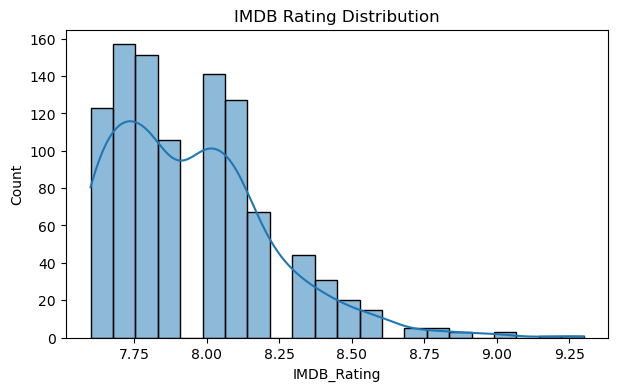

In [13]:
plt.figure(figsize=(7,4))
sns.histplot(df["IMDB_Rating"], kde=True)
plt.title("IMDB Rating Distribution")
plt.show()


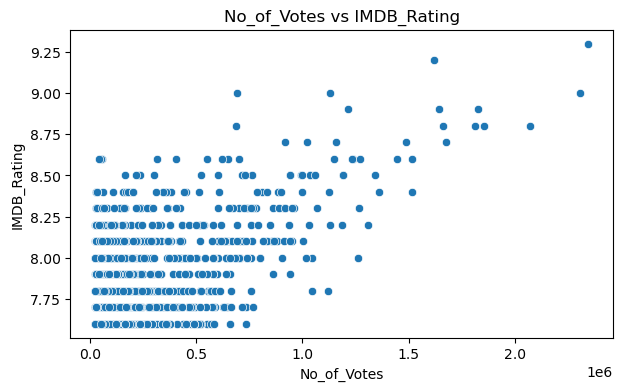

In [14]:
plt.figure(figsize=(7,4))
sns.scatterplot(x=df["No_of_Votes"], y=df["IMDB_Rating"])
plt.title("No_of_Votes vs IMDB_Rating")
plt.show()


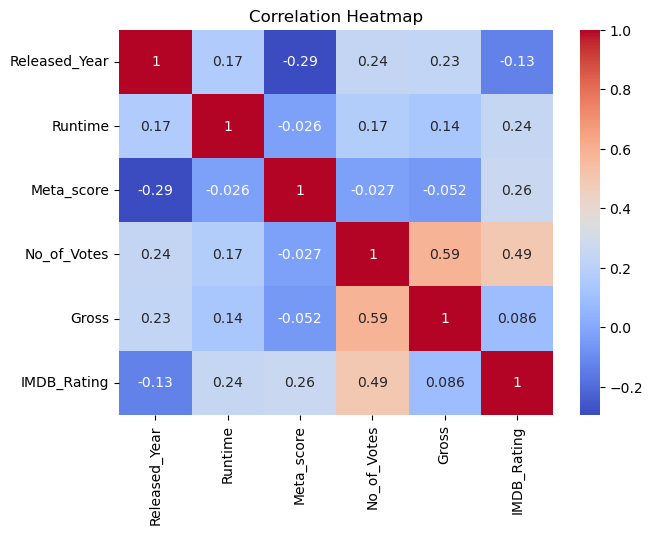

In [15]:
plt.figure(figsize=(7,5))
sns.heatmap(df[["Released_Year","Runtime","Meta_score","No_of_Votes","Gross","IMDB_Rating"]].corr(),
            annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


In [16]:
data = df[["Released_Year","Runtime","Meta_score","No_of_Votes","Gross","IMDB_Rating"]]
data.head()


,Released_Year,Runtime,Meta_score,No_of_Votes,Gross,IMDB_Rating
0,1994.0,142,80.0,2343110,28341469.0,9.3
1,1972.0,175,100.0,1620367,134966411.0,9.2
2,2008.0,152,84.0,2303232,534858444.0,9.0
3,1974.0,202,90.0,1129952,57300000.0,9.0
4,1957.0,96,96.0,689845,4360000.0,9.0


In [17]:
X = data.drop("IMDB_Rating", axis=1)
y = data["IMDB_Rating"]


In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [19]:
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)


In [20]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)


MAE : 0.16999387181220577
MSE : 0.045660657638233834
RMSE: 0.21368354554863095
R2 Score: 0.2877096961463589


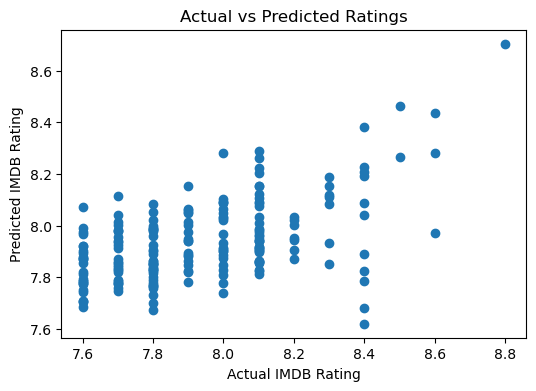

In [27]:
plt.figure(figsize=(6,4))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual IMDB Rating")
plt.ylabel("Predicted IMDB Rating")
plt.title("Actual vs Predicted Ratings")
plt.show()


In [28]:
print("The model predicts IMDB Rating using numeric movie features.")


The model predicts IMDB Rating using numeric movie features.
